## Esercizio Classificazione NLP2

In [1]:
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

path = 'https://frenzy86.s3.eu-west-2.amazonaws.com/python/text_2_clean.csv'
df = pd.read_csv(path)
df

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative
...,...,...,...,...
27476,4eac33d1c0,wish we could come see u on Denver husband l...,d lost,negative
27477,4f4c4fc327,I`ve wondered about rake to. The client has ...,", don`t force",negative
27478,f67aae2310,Yay good for both of you. Enjoy the break - y...,Yay good for both of you.,positive
27479,ed167662a5,But it was worth it ****.,But it was worth it ****.,positive


In [2]:
df.info() #problema 1 riga nulla

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


In [3]:
import re
# Add a new pattern to remove specific words
words_to_remove = ['gargamella', 'doggy', 'word3']
words_pattern = r'\b(?:' + '|'.join(map(re.escape, words_to_remove)) + r')\b'


patterns = {
            r'\s+': ' ',            # prima e dopo come ultima sostituisce tutti i multipli spazi con uno spazio
            #r'......': '',
            #r'......': '',         #aggiungere nuove regex qui
            r'\d+': '',             # remove digits (numeri)
            r'[^\w\s]': '',         # remove punteggiatura e simboli ...,'@!£$%
            r'\b\w{1,2}\b': '',      # remove all token less than2 characters
            r'(http|www)[^\s]+': '', # remove website
            r'\s+': ' ',             # sostituisce tutti i multipli spazi con uno spazio
            words_pattern:'',
            }

def clean_column(df, column, patterns):
    for pattern, replacement in patterns.items():
        df[column] = df[column].str.replace(pattern, replacement,regex=True)
        df[column] = df[column].str.lower() # applica il lower
    return df

#solo in preview
clean_column(df, 'text', patterns)

,textID,text,selected_text,sentiment
0,cb774db0d1,have responded were going,"I`d have responded, if I were going",neutral
1,549e992a42,sooo sad will miss you here san diego,Sooo SAD,negative
2,088c60f138,boss bullying,bullying me,negative
3,9642c003ef,what interview leave alone,leave me alone,negative
4,358bd9e861,sons why couldnt they put them the release...,"Sons of ****,",negative
...,...,...,...,...
27476,4eac33d1c0,wish could come see denver husband lost hi...,d lost,negative
27477,4f4c4fc327,ive wondered about rake the client has made ...,", don`t force",negative
27478,f67aae2310,yay good for both you enjoy the break you p...,Yay good for both of you.,positive
27479,ed167662a5,but was worth,But it was worth it ****.,positive


In [4]:
# applichiamo la regex
df = clean_column(df, 'text', patterns)
df

,textID,text,selected_text,sentiment
0,cb774db0d1,have responded were going,"I`d have responded, if I were going",neutral
1,549e992a42,sooo sad will miss you here san diego,Sooo SAD,negative
2,088c60f138,boss bullying,bullying me,negative
3,9642c003ef,what interview leave alone,leave me alone,negative
4,358bd9e861,sons why couldnt they put them the releases a...,"Sons of ****,",negative
...,...,...,...,...
27476,4eac33d1c0,wish could come see denver husband lost his j...,d lost,negative
27477,4f4c4fc327,ive wondered about rake the client has made c...,", don`t force",negative
27478,f67aae2310,yay good for both you enjoy the break you pro...,Yay good for both of you.,positive
27479,ed167662a5,but was worth,But it was worth it ****.,positive


In [5]:
#balancing
df['sentiment'].value_counts()

,count
sentiment,
neutral,11118
positive,8582
negative,7781


In [6]:
df['text'].head(10)

,text
0,have responded were going
1,sooo sad will miss you here san diego
2,boss bullying
3,what interview leave alone
4,sons why couldnt they put them the releases a...
5,some shameless plugging for the best rangers ...
6,feedings for the baby are fun when all smiles...
7,soooo high
8,both you
9,journey wow just became cooler hehe that poss...


In [7]:
text_neutral = list(map(str, df[df['sentiment']=='neutral']['text']))
text_positive = list(map(str, df[df['sentiment']=='positive']['text']))
text_negative = list(map(str, df[df['sentiment']=='negative']['text']))

text_neutral = ''.join(text_neutral)
text_positive = ''.join(text_positive)
text_negative = ''.join(text_negative)

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

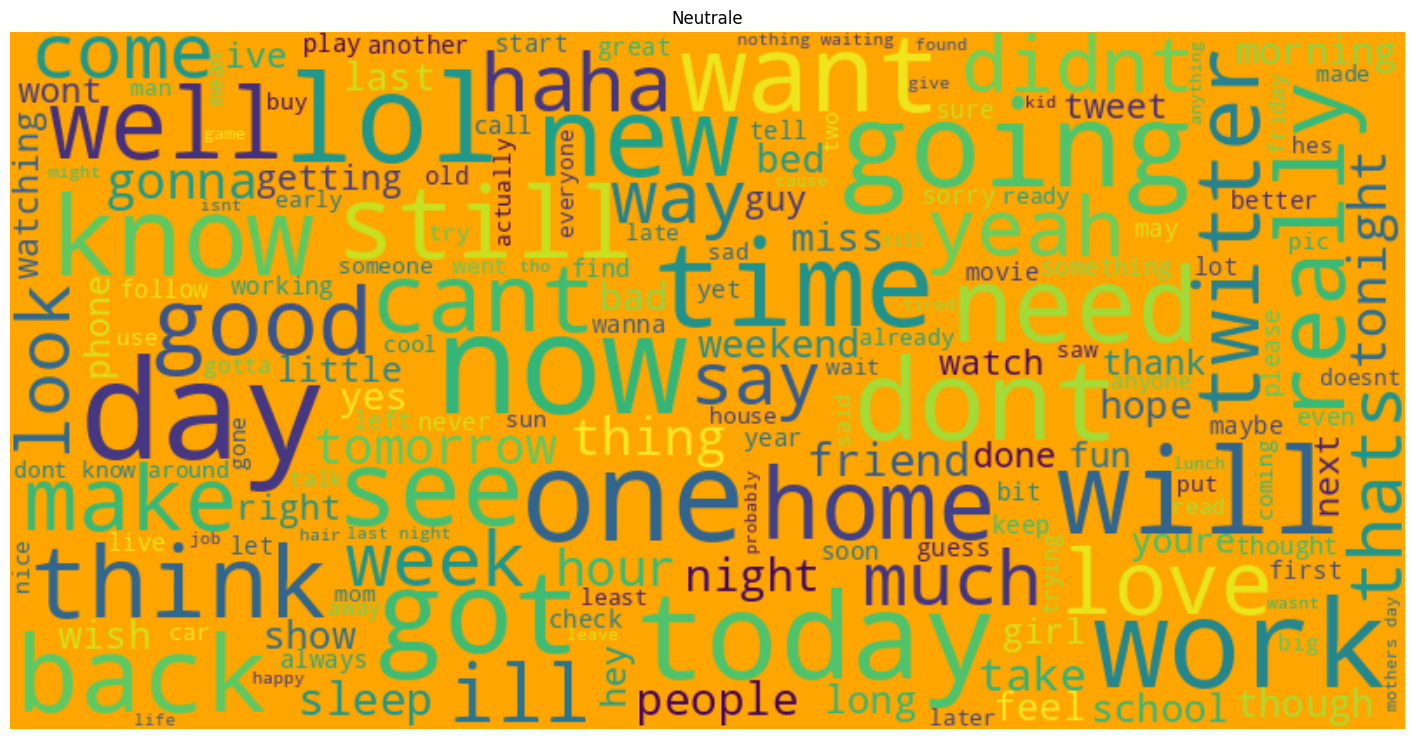

In [8]:
## STEP 2 : EDA con WORDCLOUD
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

wordcloud = WordCloud(background_color = 'orange', width = 800, height = 400,
                      max_words = 180, contour_width = 3,
                      max_font_size = 80, contour_color = 'steelblue',
                      stopwords = STOPWORDS, random_state = 667)

wordcloud.generate(text_neutral)

plt.figure(figsize=(18,10))
plt.title('Neutrale')
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis("off")

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

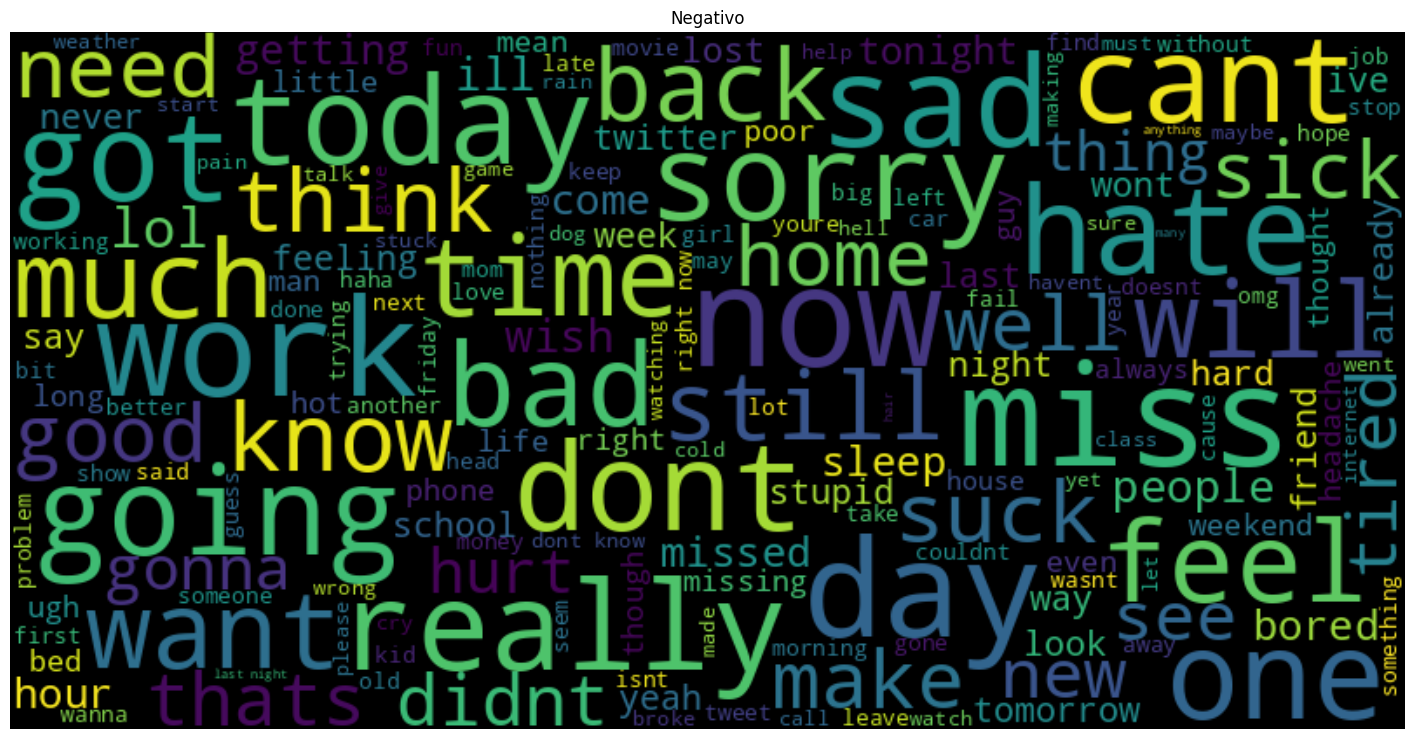

In [9]:
## STEP 2 : EDA con WORDCLOUD
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

wordcloud = WordCloud(background_color = 'black', width = 800, height = 400,
                      max_words = 180, contour_width = 3,
                      max_font_size = 80, contour_color = 'steelblue',
                      stopwords = STOPWORDS, random_state = 667)

wordcloud.generate(text_negative)

plt.figure(figsize=(18,10))
plt.title('Negativo')
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis("off")

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

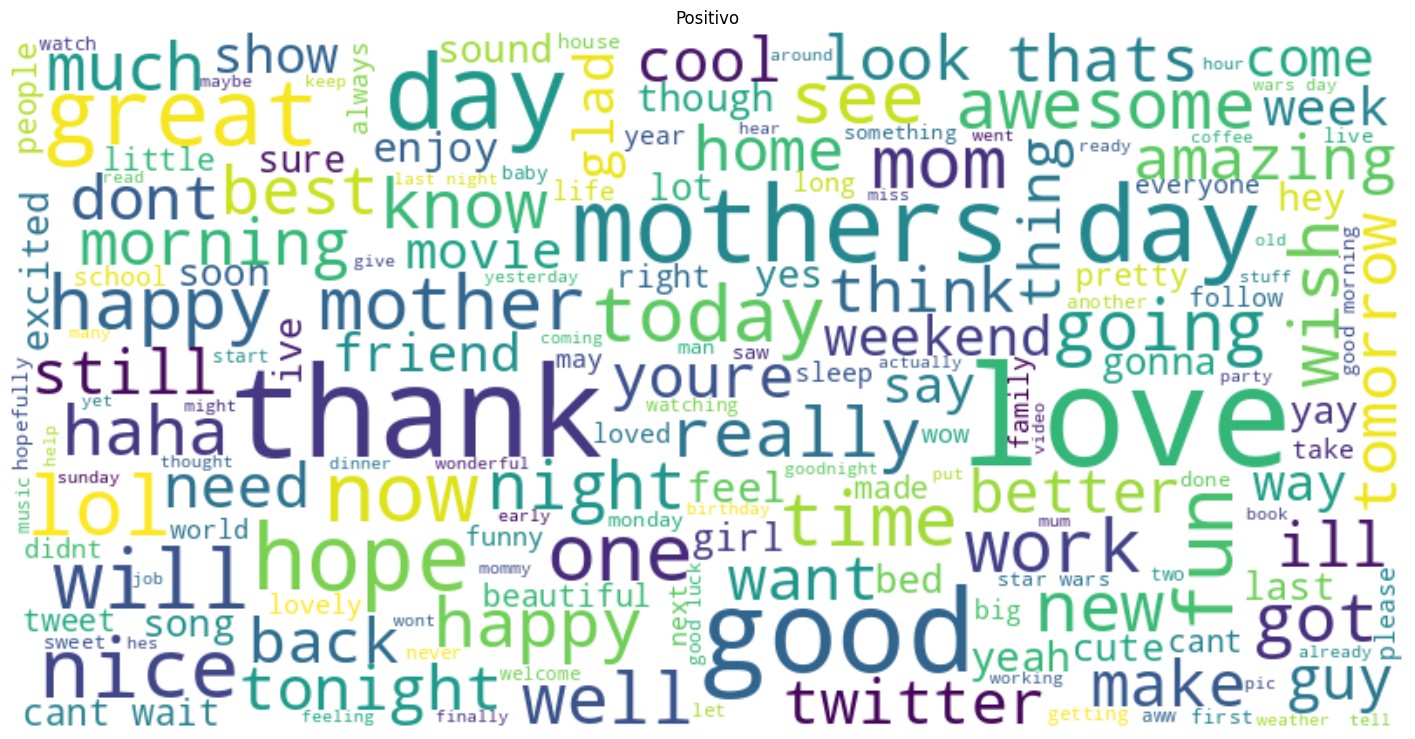

In [10]:
## STEP 2 : EDA con WORDCLOUD
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

wordcloud = WordCloud(background_color = 'white', width = 800, height = 400,
                      max_words = 180, contour_width = 3,
                      max_font_size = 80, contour_color = 'steelblue',
                      stopwords = STOPWORDS, random_state = 667)

wordcloud.generate(text_positive)

plt.figure(figsize=(18,10))
plt.title('Positivo')
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis("off")

In [11]:
df = df[['text','sentiment']]

In [12]:
df.isnull().sum()

,0
text,1
sentiment,0


In [13]:
df = df.dropna()

In [14]:
##STEP 3: Definizre X e y (features testuali e Target)
## rimuovere eventuali nan

X = df['text']      #Feature
y = df['sentiment'] #Target

print(X.shape)

(27480,)


In [15]:
##STEP 4: Count-Vettorizzazione -Bow
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(max_features=1500,
                             min_df=5, max_df=0.7,
                             stop_words='english',
                             )
#vectorizer = CountVectorizer(stop_words='english')
X_vect = vectorizer.fit_transform(X).toarray()
X_vect

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [16]:
X_vect.shape

(27480, 1500)

In [17]:
vectorizer.get_feature_names_out()

array(['able', 'absolutely', 'abt', ..., 'yum', 'yummy', 'yup'],
      dtype=object)

In [18]:
X_vect.sum(axis=0)

array([91, 45, 21, ..., 45, 43, 26])

In [ ]:
# word_counts = pd.DataFrame(zip(X_vect.sum(axis=0),vectorizer.get_feature_names_out()))
# word_counts.columns = ['frequency','words']
# word_counts = word_counts.sort_values(by='frequency', ascending=False)
# word_counts

In [19]:
##STEP 5: TF-IDF
from sklearn.feature_extraction.text import TfidfTransformer

tfidfconverter = TfidfTransformer()
X_tfidf = tfidfconverter.fit_transform(X_vect).toarray()
X_tfidf

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [20]:
##STEP 6: Split Training and Test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y,
                                                    test_size=0.3,
                                                    random_state=667,
                                                    stratify=y
                                                    )

In [21]:
##STEP 7: Modellazione
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

classifier = RandomForestClassifier(n_estimators=100,
                                    random_state=667,
                                    max_depth=5)
classifier.fit(X_train, y_train)

# accuracy score on the test data
y_pred = classifier.predict(X_test)
test_data_accuracy = accuracy_score(y_pred, y_test)
test_data_accuracy

0.4655507035419699

In [22]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))#, target_names=labels))

              precision    recall  f1-score   support

    negative       0.82      0.02      0.05      2334
     neutral       0.43      0.97      0.60      3335
    positive       0.86      0.21      0.33      2575

    accuracy                           0.47      8244
   macro avg       0.70      0.40      0.33      8244
weighted avg       0.68      0.47      0.36      8244



In [23]:
from sklearn.naive_bayes import MultinomialNB

classifier = MultinomialNB(alpha=0.1)
classifier.fit(X_train, y_train)

# accuracy score on the test data
y_pred = classifier.predict(X_test)
test_data_accuracy = accuracy_score(y_pred, y_test)
test_data_accuracy

0.638524987869966

In [25]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))#, target_names=labels))

              precision    recall  f1-score   support

    negative       0.70      0.50      0.59      2334
     neutral       0.56      0.77      0.65      3335
    positive       0.75      0.60      0.66      2575

    accuracy                           0.64      8244
   macro avg       0.67      0.62      0.63      8244
weighted avg       0.66      0.64      0.64      8244



Text(95.72222222222221, 0.5, 'Actual')

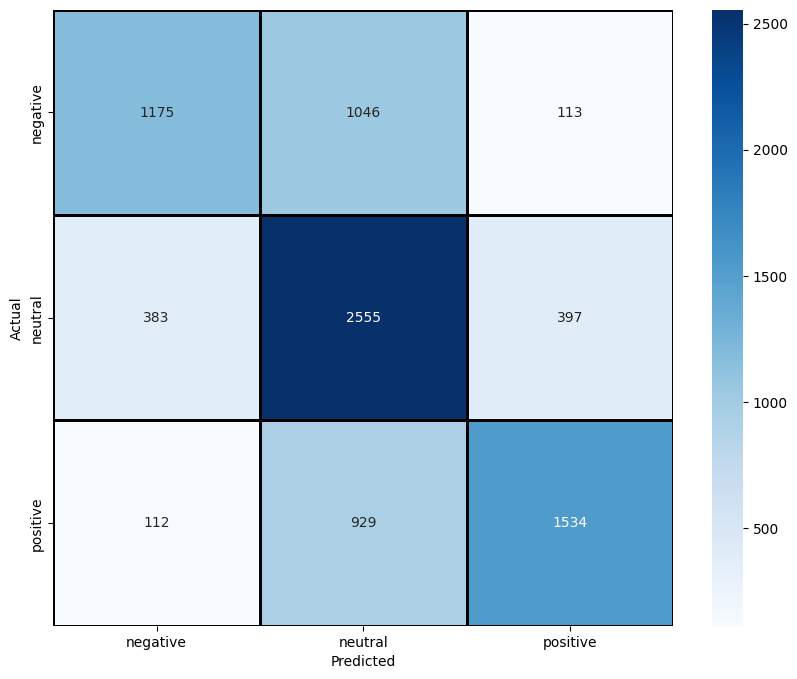

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (10,8))
sns.heatmap(cm,cmap= "Blues",
            linecolor = 'black',
            linewidth = 1,
            annot = True,
            fmt='',
            xticklabels = classifier.classes_,
            yticklabels = classifier.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")

In [29]:
# accuracy score on the test data
from sklearn.linear_model import SGDClassifier

classifier = SGDClassifier(penalty='l2',alpha=1e-3, random_state=667, max_iter=5, tol=None)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)
test_data_accuracy = accuracy_score(y_test,y_pred)
test_data_accuracy

0.6770984958757884

## Pipeline Finale

In [ ]:
## Pipeline Finale

In [30]:
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

path = 'https://frenzy86.s3.eu-west-2.amazonaws.com/python/text_2_clean.csv'
df = pd.read_csv(path)
df

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative
...,...,...,...,...
27476,4eac33d1c0,wish we could come see u on Denver husband l...,d lost,negative
27477,4f4c4fc327,I`ve wondered about rake to. The client has ...,", don`t force",negative
27478,f67aae2310,Yay good for both of you. Enjoy the break - y...,Yay good for both of you.,positive
27479,ed167662a5,But it was worth it ****.,But it was worth it ****.,positive


In [31]:
df.isnull().sum()

,0
textID,0
text,1
selected_text,1
sentiment,0


In [32]:
df = df.dropna()

In [33]:
X = df['text']
y = df['sentiment']

In [34]:
patterns = {
            r'\s+': ' ',            # prima e dopo come ultima sostituisce tutti i multipli spazi con uno spazio
            #r'......': '',
            #r'......': '',         #aggiungere nuove regex qui
            r'\d+': '',             # remove digits (numeri)
            r'[^\w\s]': '',         # remove punteggiatura e simboli ...,'@!£$%
            r'\b\w{1,2}\b': '',      # remove all token less than2 characters
            r'(http|www)[^\s]+': '', # remove website
            r'\s+': ' ',             # sostituisce tutti i multipli spazi con uno spazio
            #words_pattern:'',
            }

def clean_column(df, column, patterns):
    df[column] = df[column].str.lower() # Apply lowercase transformation
    for pattern, replacement in patterns.items():
        df[column] = df[column].str.replace(pattern, replacement, regex=True)
    return df

In [35]:
from sklearn.base import BaseEstimator, TransformerMixin

class TextCleaner(BaseEstimator, TransformerMixin):
    def __init__(self, patterns):
        self.patterns = patterns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = pd.DataFrame(X, columns=['text'])
        df = clean_column(df, 'text', self.patterns)
        return df['text'].values

In [41]:
# Step 8: Pipeline Finale (nuovo train test split su dati raw tetuali)
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=667
                                                    )

from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB

text_cleaner = TextCleaner(patterns)
bow = CountVectorizer(max_features=1500, min_df=5, max_df=0.7,stop_words='english')
tfidf = TfidfTransformer()
classifier = MultinomialNB(alpha=0.1)

pipe = Pipeline([
                ('text_cleaner', text_cleaner),  ## Regex and clean
                ('bow', bow),                    ## BoW
                #('tfidf', tfidf),                ## TF-IDF
                ('classifier', classifier),             ## Classifier
                ])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)

test_data_accuracy = accuracy_score(y_test,y_pred)
print('Accuracy score of the test data : ', test_data_accuracy)

Accuracy score of the test data :  0.6562348374575449


In [42]:
from sklearn.metrics import classification_report
#labels = ['class1', 'class2']
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.68      0.59      0.63      2302
     neutral       0.60      0.71      0.65      3368
    positive       0.73      0.65      0.69      2574

    accuracy                           0.66      8244
   macro avg       0.67      0.65      0.66      8244
weighted avg       0.66      0.66      0.66      8244



Text(95.72222222222221, 0.5, 'Actual')

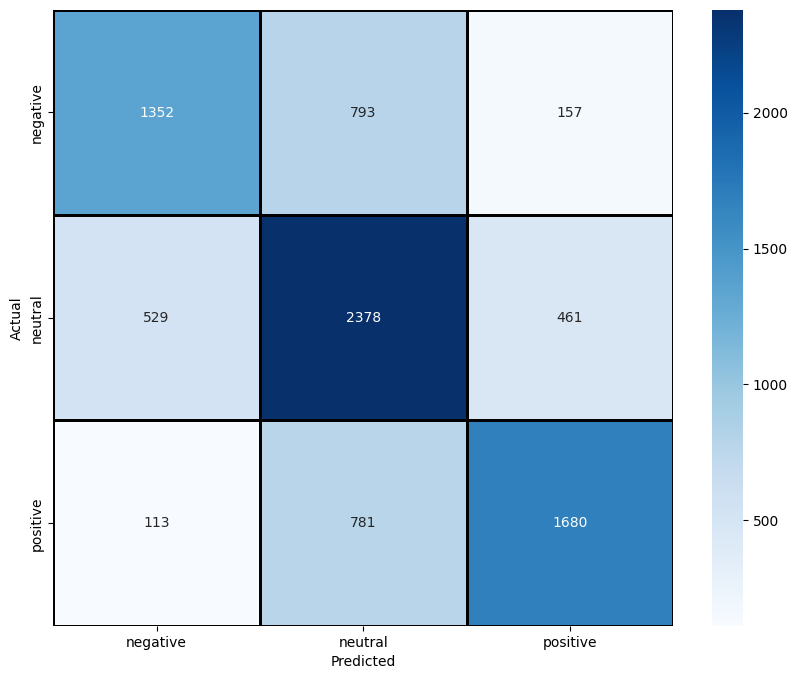

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (10,8))
sns.heatmap(cm,cmap= "Blues",
            linecolor = 'black',
            linewidth = 1,
            annot = True,
            fmt='',
            xticklabels = classifier.classes_,
            yticklabels = classifier.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")

In [44]:
# Step 10: Cross Validation
from sklearn.model_selection import cross_val_score
scores = cross_val_score(pipe, X, y, scoring = 'f1_micro', cv = 8)

print(f'scores={scores}')
print(f'mean={np.mean(scores)}')
print(f'std={np.std(scores)}')

scores=[0.66055313 0.65705968 0.65531295 0.66200873 0.6768559  0.66695779
 0.65822416 0.6588064 ]
mean=0.6619723435225618
std=0.0065282463445222256


## Fitting di tutto il Dataset

In [45]:
pipe.fit(X, y)

Pipeline(steps=[('text_cleaner',
                 TextCleaner(patterns={'(http|www)[^\\s]+': '', '[^\\w\\s]': '',
                                       '\\b\\w{1,2}\\b': '', '\\d+': '',
                                       '\\s+': ' '})),
                ('bow',
                 CountVectorizer(max_df=0.7, max_features=1500, min_df=5,
                                 stop_words='english')),
                ('classifier', MultinomialNB(alpha=0.1))])

In [46]:
import joblib
joblib.dump(pipe,'NLPEs2.pkl')

['NLPEs2.pkl']

In [47]:
import joblib

uploaded_model = joblib.load('NLPEs2.pkl')
uploaded_model

Pipeline(steps=[('text_cleaner',
                 TextCleaner(patterns={'(http|www)[^\\s]+': '', '[^\\w\\s]': '',
                                       '\\b\\w{1,2}\\b': '', '\\d+': '',
                                       '\\s+': ' '})),
                ('bow',
                 CountVectorizer(max_df=0.7, max_features=1500, min_df=5,
                                 stop_words='english')),
                ('classifier', MultinomialNB(alpha=0.1))])

In [54]:
pred = uploaded_model.predict(['very beautiful']) # positive
pred = uploaded_model.predict(['I am feeling tired']) # positive
#pred = uploaded_model.predict(['I hate you']) # negative
pred[0]

np.str_('negative')